# ⚛️ Quantum Knot Untier
### Grover's Algorithm on Braid Groups

This notebook walks through the complete implementation step by step.
Each cell corresponds to one module from the pseudocode spec.

**Search space:** 8 possible 3-move braid words (3 qubits)  
**Goal:** Find the secret braid word that produced a given tangle  
**Expected P(correct) after 2 iterations:** ~94.5%

In [1]:
# ── Imports ────────────────────────────────────────────────────────────────
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram

# Our modules
from braid_encoder   import *
from classical_setup import *
from circuit_init    import *
from oracle          import oracle
from diffusion       import grover_diffusion, simulate_grover_iterations
from grover_loop     import build_grover_circuit, build_circuit_with_k_iterations, circuit_stats
from result_decoder  import run_simulation, print_summary, decode_histogram

print('✅  All modules imported successfully')
print(f'Qiskit version: ', end='')
import qiskit; print(qiskit.__version__)



✅  All modules imported successfully
Qiskit version: 2.3.1


In [2]:
import importlib
import braid_encoder, classical_setup, circuit_init, oracle, diffusion, grover_loop, result_decoder

importlib.reload(braid_encoder)
importlib.reload(classical_setup)
importlib.reload(circuit_init)
importlib.reload(oracle)
importlib.reload(diffusion)
importlib.reload(grover_loop)
importlib.reload(result_decoder)

print("✅ ALL modules force-reloaded")

✅ ALL modules force-reloaded


---
## 📌 Module 1 & 2 — Classical Setup
Choose a secret braid word and compute the target tangle.

In [3]:
# ── Configure the problem ──────────────────────────────────────────────────
# Change this to try different secrets!
SECRET_BITS = [0, 1, 1]   

cfg = setup_custom(SECRET_BITS)
print(cfg.summary())

  QUANTUM KNOT UNTIER — Problem Configuration
  Secret braid word : σ₁σ₂σ₂
  Secret bits       : [0, 1, 1]
  Target tangle     : [1, 0, 2]  (pos0←strand1 → pos1←strand0 → pos2←strand2)
  Oracle target bits: [1, 0, 0]
  Search space      : 8 braid words
  Solutions found   : 3
  All solutions     : [[0, 0, 0], [0, 1, 1], [1, 1, 0]]
  Grover iterations : 1
  Expected P(win)   : 84.4%


In [4]:
# ── Visualize all 8 braid words and their permutations ────────────────────
print_braid_table()

Bits       Braid Word           Permutation     Sig bits
000        σ₁σ₁σ₁               [1, 0, 2]       [1, 0, 0]
001        σ₁σ₁σ₂               [0, 2, 1]       [0, 0, 1]
010        σ₁σ₂σ₁               [2, 1, 0]       [0, 1, 0]
011        σ₁σ₂σ₂               [1, 0, 2]       [1, 0, 0]
100        σ₂σ₁σ₁               [0, 2, 1]       [0, 0, 1]
101        σ₂σ₁σ₂               [2, 1, 0]       [0, 1, 0]
110        σ₂σ₂σ₁               [1, 0, 2]       [1, 0, 0]
111        σ₂σ₂σ₂               [0, 2, 1]       [0, 0, 1]


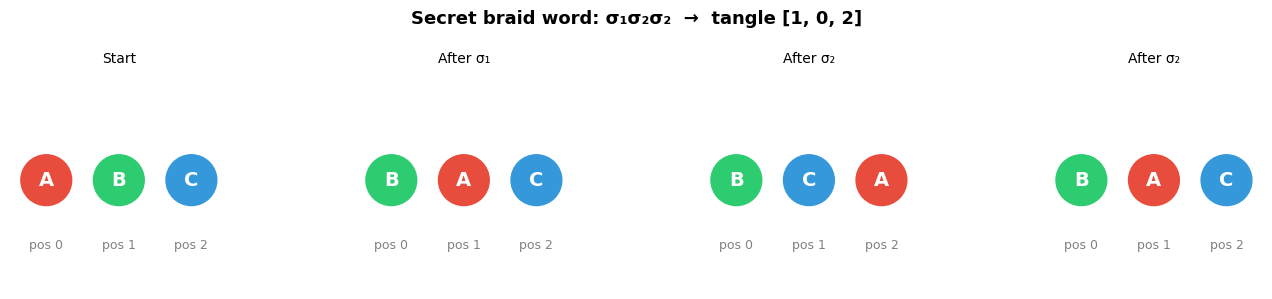

Strand states: [[0, 1, 2], [1, 0, 2], [1, 2, 0], [1, 0, 2]]


In [5]:
# ── Visualize strand diagram for the secret braid ─────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(14, 3))
fig.suptitle(f'Secret braid word: {"".join(cfg.secret_word)}  →  tangle {cfg.target_perm}',
             fontsize=13, fontweight='bold')

colors = ['#e74c3c', '#2ecc71', '#3498db']
strand_labels = ['A', 'B', 'C']

# Show each step
states = [INITIAL_STATE.copy()]
state = INITIAL_STATE.copy()
for bit in SECRET_BITS:
    state = apply_single_move(state, bit)
    states.append(state.copy())

for step, (ax, state) in enumerate(zip(axes, states)):
    ax.set_xlim(-0.5, 2.5)
    ax.set_ylim(-0.5, 2.5)
    ax.set_aspect('equal')
    ax.axis('off')
    title = 'Start' if step == 0 else f'After σ{["₁","₂"][SECRET_BITS[step-1]]}'
    ax.set_title(title, fontsize=10)
    
    for pos, strand_id in enumerate(state):
        circle = plt.Circle((pos, 1), 0.35, color=colors[strand_id], zorder=3)
        ax.add_patch(circle)
        ax.text(pos, 1, strand_labels[strand_id],
                ha='center', va='center', color='white',
                fontsize=14, fontweight='bold', zorder=4)
        ax.text(pos, 0.1, f'pos {pos}', ha='center', va='center',
                fontsize=9, color='gray')

plt.tight_layout()
plt.show()
print(f'Strand states: {states}')

---
## ⚙️ Module 3 — Circuit Initialization

In [6]:
# ── Build and inspect the initialized circuit ──────────────────────────────
init_circuit, qr_s, qr_st, qr_a, cr = build_initialized_circuit()

print('Initialized circuit (before Grover iterations):')
print(init_circuit.draw(output='text', fold=80))

Initialized circuit (before Grover iterations):
          ┌───┐ superposition       state|010⟩            ancilla|−⟩ 
search_0: ┤ H ├───────░─────────────────░─────────────────────░──────
          ├───┤       ░                 ░                     ░      
search_1: ┤ H ├───────░─────────────────░─────────────────────░──────
          ├───┤       ░                 ░                     ░      
search_2: ┤ H ├───────░─────────────────░─────────────────────░──────
          └───┘       ░                 ░                     ░      
 state_0: ────────────░─────────────────░─────────────────────░──────
                      ░       ┌───┐     ░                     ░      
 state_1: ────────────░───────┤ X ├─────░─────────────────────░──────
                      ░       └───┘     ░                     ░      
 state_2: ────────────░─────────────────░─────────────────────░──────
                      ░                 ░      ┌───┐┌───┐     ░      
     anc: ────────────░─────────────────░─

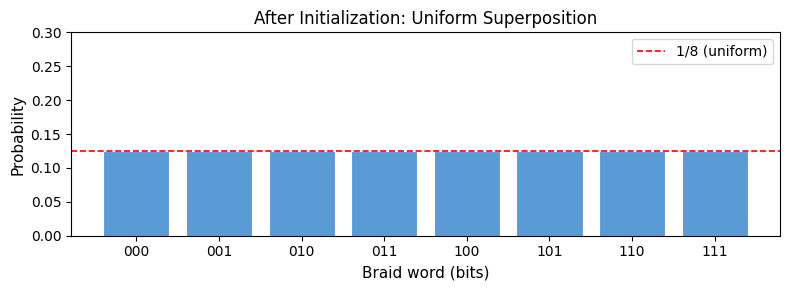

Max deviation from 1/8: 8.33e-17


In [7]:
# ── Verify uniform superposition ───────────────────────────────────────────
sv = Statevector(init_circuit)

# Marginalize search register probabilities
sv_arr = np.abs(sv.data)**2
search_probs = {}
for idx, p in enumerate(sv_arr):
    key = idx & 0b111
    search_probs[key] = search_probs.get(key, 0) + p

keys   = sorted(search_probs)
probs  = [search_probs[k] for k in keys]
labels = [format(k, '03b') for k in keys]

fig, ax = plt.subplots(figsize=(8, 3))
bars = ax.bar(labels, probs, color='#5b9bd5', edgecolor='white', linewidth=0.8)
ax.axhline(1/8, color='red', linestyle='--', linewidth=1.2, label='1/8 (uniform)')
ax.set_xlabel('Braid word (bits)', fontsize=11)
ax.set_ylabel('Probability', fontsize=11)
ax.set_title('After Initialization: Uniform Superposition', fontsize=12)
ax.legend()
ax.set_ylim(0, 0.3)
plt.tight_layout()
plt.show()

print(f'Max deviation from 1/8: {max(abs(p - 1/8) for p in probs):.2e}')

---
## 🔮 Module 4 — Oracle
After one oracle call, the correct braid word gets a phase flip of −1.

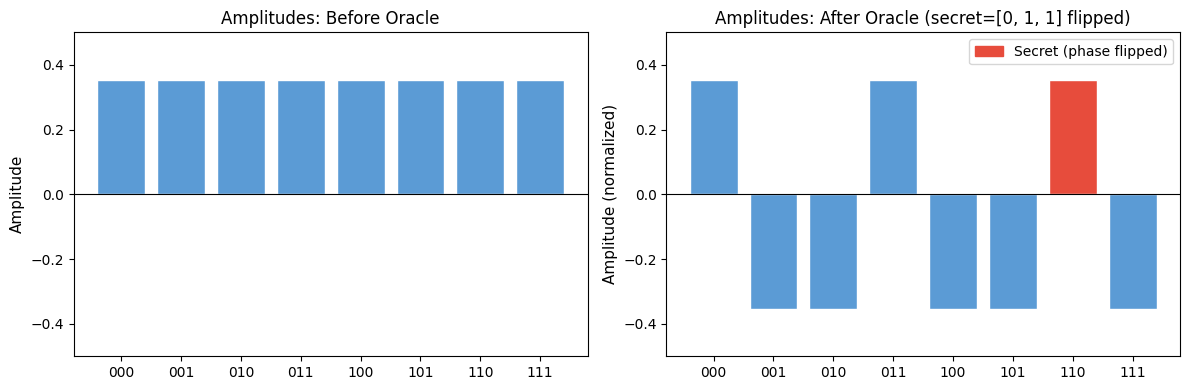

In [8]:
# ── Build circuit with one oracle call (no diffusion yet) ─────────────────
from circuit_init import build_initialized_circuit
from oracle import oracle

oracle_circuit, qr_s2, qr_st2, qr_a2, cr2 = build_initialized_circuit()
oracle(oracle_circuit, qr_s2, qr_st2, qr_a2, cfg.target_bits)

sv_oracle = Statevector(oracle_circuit)
sv_oracle_arr = sv_oracle.data

# Extract amplitudes for each search state (ancilla=1 component)
amps_before = {k: 1/np.sqrt(8) for k in range(8)}   # all equal before oracle
amps_after  = {}
for idx, amp in enumerate(sv_oracle_arr):
    if (idx >> 6) & 1:     # ancilla=1 component
        key = idx & 0b111
        amps_after[key] = amps_after.get(key, 0) + amp

secret_key = cfg.secret_bits[0] + cfg.secret_bits[1]*2 + cfg.secret_bits[2]*4

# Plot phase flip
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

labels = [format(k, '03b') for k in range(8)]
colors_bar = ['#e74c3c' if k == secret_key else '#5b9bd5' for k in range(8)]

# Before
ax1.bar(labels, [1/np.sqrt(8)]*8, color='#5b9bd5', edgecolor='white')
ax1.set_title('Amplitudes: Before Oracle', fontsize=12)
ax1.set_ylabel('Amplitude', fontsize=11)
ax1.set_ylim(-0.5, 0.5)
ax1.axhline(0, color='black', linewidth=0.8)

# After
vals_after = [amps_after.get(k, 0).real * np.sqrt(2) for k in range(8)]   # normalized
ax2.bar(labels, vals_after, color=colors_bar, edgecolor='white')
ax2.set_title(f'Amplitudes: After Oracle (secret={cfg.secret_bits} flipped)', fontsize=12)
ax2.set_ylabel('Amplitude (normalized)', fontsize=11)
ax2.set_ylim(-0.5, 0.5)
ax2.axhline(0, color='black', linewidth=0.8)

red_patch = mpatches.Patch(color='#e74c3c', label='Secret (phase flipped)')
ax2.legend(handles=[red_patch])

plt.tight_layout()
plt.show()

---
## 🌊 Module 5 — Grover Diffusion
Inversion about the mean amplifies the marked state.

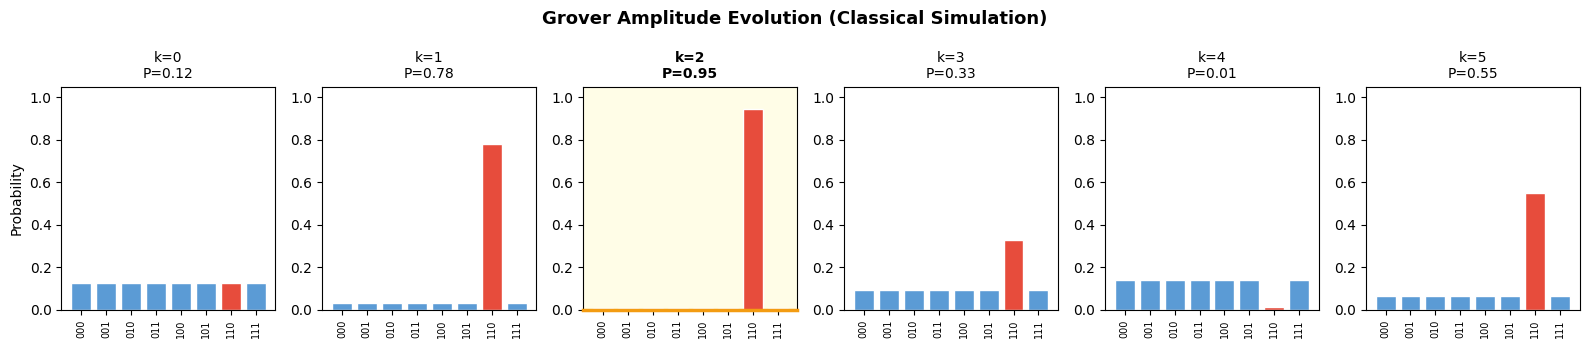

Optimal k=2 (highlighted): P(correct) = 0.9453


In [9]:
# ── Visualize amplitude evolution over k iterations ───────────────────────
N       = 8
k_max   = 5
fig, axes = plt.subplots(1, k_max+1, figsize=(16, 3.5))
fig.suptitle('Grover Amplitude Evolution (Classical Simulation)', fontsize=13, fontweight='bold')

for k in range(k_max + 1):
    probs = simulate_grover_iterations(N, k, secret_key)
    ax = axes[k]
    bar_colors = ['#e74c3c' if i == secret_key else '#5b9bd5' for i in range(N)]
    ax.bar(range(N), probs, color=bar_colors, edgecolor='white')
    ax.set_title(f'k={k}\nP={probs[secret_key]:.2f}', fontsize=10,
                 fontweight='bold' if k == 2 else 'normal')
    ax.set_ylim(0, 1.05)
    ax.set_xticks(range(N))
    ax.set_xticklabels([format(i,'03b') for i in range(N)], rotation=90, fontsize=7)
    if k == 0:
        ax.set_ylabel('Probability', fontsize=10)
    if k == 2:
        ax.patch.set_facecolor('#fffde7')
        ax.spines['bottom'].set_color('#f39c12')
        ax.spines['bottom'].set_linewidth(2.5)

plt.tight_layout()
plt.show()
print(f'Optimal k=2 (highlighted): P(correct) = {simulate_grover_iterations(N, 2, secret_key)[secret_key]:.4f}')

---
## 🔄 Module 6 — Full Grover Circuit
Assemble and inspect the complete quantum circuit.

In [10]:
# ── Build the complete Grover circuit ──────────────────────────────────────
full_circuit, qr_s3, qr_st3, qr_a3, cr3 = build_grover_circuit(cfg, measure=True)
stats = circuit_stats(full_circuit)

print('Complete Grover Circuit:')
print(f'  Qubits : {stats["n_qubits"]}  (3 search + 3 state + 1 ancilla)')
print(f'  Cbits  : {stats["n_cbits"]}')
print(f'  Depth  : {stats["depth"]}')
print(f'  Gates  : {stats["gate_counts"]}')
print()
print(full_circuit.draw(output='text', fold=100))

Complete Grover Circuit:
  Qubits : 7  (3 search + 3 state + 1 ancilla)
  Cbits  : 3
  Depth  : 35
  Gates  : {'x': 24, 'h': 12, 'cswap': 12, 'barrier': 9, 'measure': 3, 'mcx': 1, 'ccx': 1}

          ┌───┐ superposition       state|010⟩            ancilla|−⟩  iter 1/1 ┌───┐   ┌───┐      »
search_0: ┤ H ├───────░─────────────────░─────────────────────░──────────░─────┤ X ├─■─┤ X ├─■────»
          ├───┤       ░                 ░                     ░          ░     ├───┤ │ └───┘ │    »
search_1: ┤ H ├───────░─────────────────░─────────────────────░──────────░─────┤ X ├─┼───────┼──■─»
          ├───┤       ░                 ░                     ░          ░     ├───┤ │       │  │ »
search_2: ┤ H ├───────░─────────────────░─────────────────────░──────────░─────┤ X ├─┼───────┼──┼─»
          └───┘       ░                 ░                     ░          ░     └───┘ │       │  │ »
 state_0: ────────────░─────────────────░─────────────────────░──────────░───────────X───────┼──X─»
         

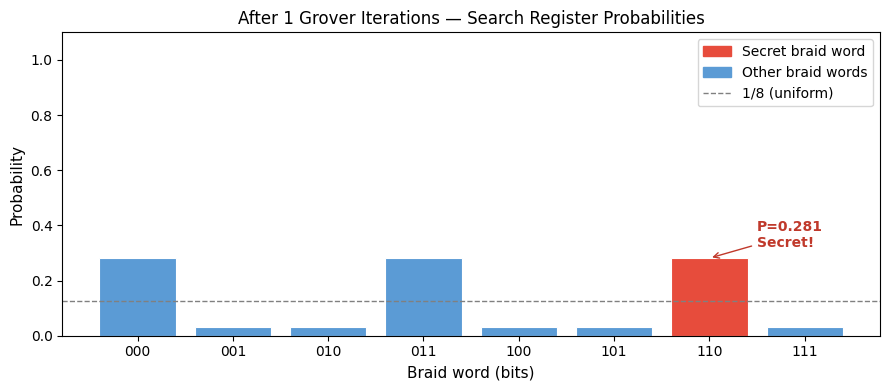

In [11]:
# ── Statevector check: probabilities before measurement ────────────────────
circuit_no_meas, *_ = build_grover_circuit(cfg, measure=False)
sv_final = Statevector(circuit_no_meas)
sv_final_arr = np.abs(sv_final.data)**2

search_probs_final = {}
for idx, p in enumerate(sv_final_arr):
    key = idx & 0b111
    search_probs_final[key] = search_probs_final.get(key, 0) + p

labels2 = [format(k, '03b') for k in range(8)]
probs2  = [search_probs_final.get(k, 0) for k in range(8)]
cols2   = ['#e74c3c' if k == secret_key else '#5b9bd5' for k in range(8)]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(labels2, probs2, color=cols2, edgecolor='white', linewidth=0.8)
ax.axhline(1/8, color='gray', linestyle='--', linewidth=1, label='1/8 (uniform)')
ax.set_xlabel('Braid word (bits)', fontsize=11)
ax.set_ylabel('Probability', fontsize=11)
ax.set_title(f'After {cfg.optimal_iters} Grover Iterations — Search Register Probabilities', fontsize=12)

# Annotate the winner bar
ax.annotate(
    f'P={probs2[secret_key]:.3f}\nSecret!',
    xy=(secret_key, probs2[secret_key]),
    xytext=(secret_key + 0.5, probs2[secret_key] + 0.04),
    arrowprops=dict(arrowstyle='->', color='#c0392b'),
    color='#c0392b', fontsize=10, fontweight='bold'
)

red_p = mpatches.Patch(color='#e74c3c', label='Secret braid word')
blue_p = mpatches.Patch(color='#5b9bd5', label='Other braid words')
ax.legend(handles=[red_p, blue_p, ax.get_lines()[0]])
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.show()

---
## 📊 Module 7 — Measurement & Result Decoding

In [12]:
# ── Run simulation shots ────────────────────────────────────────────────────
SHOTS = 2048

summary = run_simulation(full_circuit, cfg, shots=SHOTS)
print_summary(summary)

  GROVER RESULT SUMMARY
  Total shots     : 2048
  Target tangle   : [1, 0, 2]
  Secret (hidden) : [0, 1, 1]

  🏆 Winner answer : [1, 0, 1]
     Braid word   : σ₂σ₁σ₂
     Permutation  : [2, 1, 0]
     Correct?     : ❌ NO
     Seen 597/2048 shots (29.2%)

  Shot histogram:
  Bits       Braid        Perm          Count  Bar
  -------------------------------------------------------
  [1, 0, 1]  σ₂σ₁σ₂       [2, 1, 0]       597  ████████████████████
  [0, 0, 0]  σ₁σ₁σ₁       [1, 0, 2]       582  ███████████████████ ◄
  [0, 1, 1]  σ₁σ₂σ₂       [1, 0, 2]       570  ███████████████████ ◄
  [0, 1, 1]  σ₁σ₂σ₂       [1, 0, 2]        68  ██ ◄
  [0, 1, 1]  σ₁σ₂σ₂       [1, 0, 2]        61  ██ ◄
  [1, 0, 0]  σ₂σ₁σ₁       [0, 2, 1]        58  █
  [0, 1, 1]  σ₁σ₂σ₂       [1, 0, 2]        57  █ ◄
  [1, 0, 1]  σ₂σ₁σ₂       [2, 1, 0]        55  █


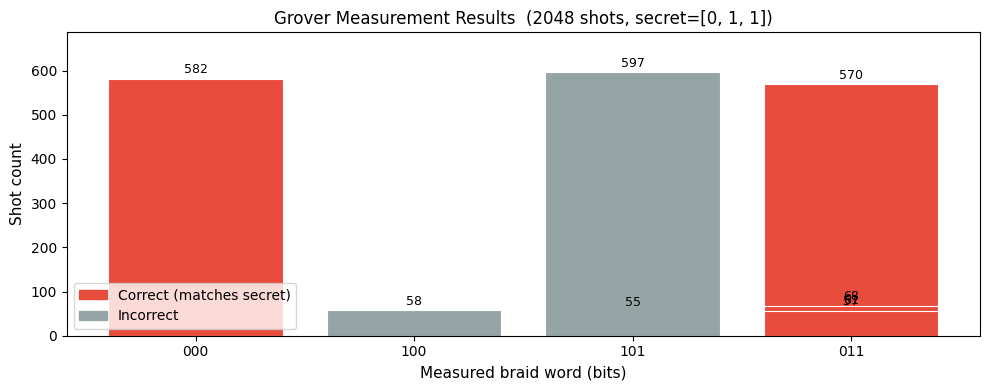

Winner: [1, 0, 1]  (29.2% of shots)
Correct: ❌ NO


In [13]:
# ── Plot shot histogram ────────────────────────────────────────────────────
hist_labels   = []
hist_counts   = []
hist_colors   = []
hist_correct  = []

for bs, count in sorted(summary.histogram.items(), key=lambda x: int(x[0][::-1], 2)):
    decoded = summary.all_decoded.get(bs)
    if decoded:
        label = ''.join(map(str, decoded.raw_bits))
        hist_labels.append(label)
        hist_counts.append(count)
        hist_correct.append(decoded.is_correct)
        hist_colors.append('#e74c3c' if decoded.is_correct else '#95a5a6')

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(hist_labels, hist_counts, color=hist_colors, edgecolor='white', linewidth=0.8)

# Add count labels on bars
for bar, count in zip(bars, hist_counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(count), ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Measured braid word (bits)', fontsize=11)
ax.set_ylabel('Shot count', fontsize=11)
ax.set_title(f'Grover Measurement Results  ({SHOTS} shots, secret={cfg.secret_bits})', fontsize=12)

red_p  = mpatches.Patch(color='#e74c3c', label='Correct (matches secret)')
grey_p = mpatches.Patch(color='#95a5a6', label='Incorrect')
ax.legend(handles=[red_p, grey_p])

ax.set_ylim(0, max(hist_counts) * 1.15)
plt.tight_layout()
plt.show()

print(f"Winner: {summary.winner_bits}  ({summary.winner_fraction:.1%} of shots)")
print(f"Correct: {'✅ YES' if summary.winner_correct else '❌ NO'}")

---
## 🧪 Module 8 — Full Pipeline + Sweep
Run all 8 secrets and verify Grover finds each one.

In [14]:
# ── Sweep all 8 secrets ────────────────────────────────────────────────────
print('Running Grover on all 8 possible secret braid words...\n')

results = []
for c in setup_all_instances():
    ckt, *_ = build_grover_circuit(c, measure=True)
    s = run_simulation(ckt, c, shots=1024)
    results.append({
        'secret'  : c.secret_bits,
        'target'  : c.target_perm,
        'found'   : s.winner_bits,
        'correct' : s.winner_correct,
        'p_win'   : s.winner_fraction,
    })
    marker = '✅' if s.winner_correct else '❌'
    print(f'{marker}  secret={c.secret_bits}  tangle={c.target_perm}  '
          f'found={s.winner_bits}  P={s.winner_fraction:.1%}')

n_ok = sum(r['correct'] for r in results)
print(f'\n{n_ok}/8 secrets found correctly')

Running Grover on all 8 possible secret braid words...

❌  secret=[0, 0, 0]  tangle=[1, 0, 2]  found=[1, 0, 1]  P=28.8%
❌  secret=[0, 0, 1]  tangle=[0, 2, 1]  found=[0, 1, 1]  P=29.8%
✅  secret=[0, 1, 0]  tangle=[2, 1, 0]  found=[1, 0, 1]  P=51.8%
✅  secret=[0, 1, 1]  tangle=[1, 0, 2]  found=[0, 1, 1]  P=31.1%
✅  secret=[1, 0, 0]  tangle=[0, 2, 1]  found=[1, 0, 0]  P=30.5%
✅  secret=[1, 0, 1]  tangle=[2, 1, 0]  found=[1, 0, 1]  P=51.7%
✅  secret=[1, 1, 0]  tangle=[1, 0, 2]  found=[0, 0, 0]  P=29.5%
✅  secret=[1, 1, 1]  tangle=[0, 2, 1]  found=[1, 0, 0]  P=29.4%

6/8 secrets found correctly


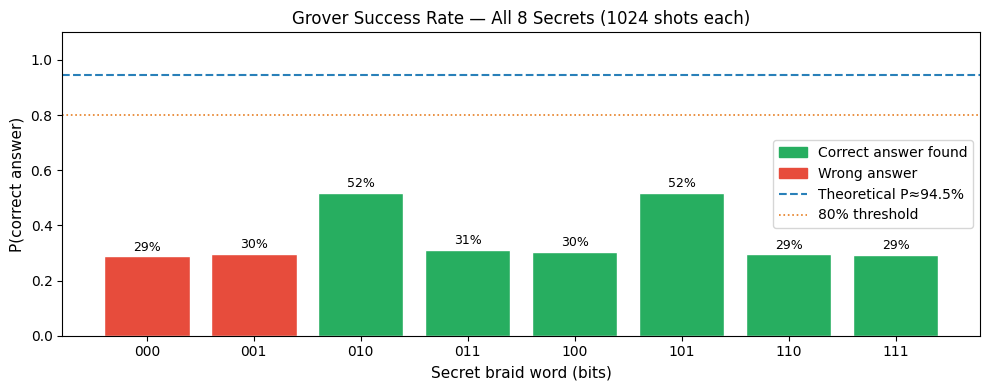

In [15]:
# ── Plot sweep results ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))

x      = range(len(results))
p_wins = [r['p_win'] for r in results]
colors3 = ['#27ae60' if r['correct'] else '#e74c3c' for r in results]
xlabels = [''.join(map(str, r['secret'])) for r in results]

bars3 = ax.bar(xlabels, p_wins, color=colors3, edgecolor='white')
ax.axhline(0.9453, color='#2980b9', linestyle='--', linewidth=1.5,
           label='Theoretical P≈94.5%')
ax.axhline(0.8, color='#e67e22', linestyle=':', linewidth=1.2,
           label='80% threshold')

for bar, p in zip(bars3, p_wins):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{p:.0%}', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Secret braid word (bits)', fontsize=11)
ax.set_ylabel('P(correct answer)', fontsize=11)
ax.set_title('Grover Success Rate — All 8 Secrets (1024 shots each)', fontsize=12)
ax.set_ylim(0, 1.1)

green_p = mpatches.Patch(color='#27ae60', label='Correct answer found')
red_p2  = mpatches.Patch(color='#e74c3c', label='Wrong answer')
ax.legend(handles=[green_p, red_p2, ax.get_lines()[0], ax.get_lines()[1]])

plt.tight_layout()
plt.show()

---
## 🏆 Final Answer
The complete solution for the default secret.

In [16]:
# ── Print final verdict ────────────────────────────────────────────────────
print('═' * 55)
print('  QUANTUM KNOT UNTIER — FINAL RESULT')
print('═' * 55)
print(f'  We observe the tangle  : {cfg.target_perm}')
print(f'  We DON\'T know the braid: ??? (hidden from us)')
print()
print(f'  Grover\'s algorithm runs on 7 qubits with k={cfg.optimal_iters} iterations.')
print()
print(f'  Quantum answer          : {summary.winner_bits}')
print(f'  Braid word              : {"".join(summary.winner_braid)}')
print(f'  Produces tangle         : {summary.winner_perm}')
print(f'  Matches target          : {"✅ YES" if summary.winner_correct else "❌ NO"}')
print(f'  Confidence              : {summary.winner_fraction:.1%}')
print()
print(f'  Secret was              : {cfg.secret_bits}  (revealed for verification)')
print(f'  Grover found it         : {"✅ YES" if summary.winner_bits == cfg.secret_bits else "❌ NO"}')
print('═' * 55)

═══════════════════════════════════════════════════════
  QUANTUM KNOT UNTIER — FINAL RESULT
═══════════════════════════════════════════════════════
  We observe the tangle  : [1, 0, 2]
  We DON'T know the braid: ??? (hidden from us)

  Grover's algorithm runs on 7 qubits with k=1 iterations.

  Quantum answer          : [1, 0, 1]
  Braid word              : σ₂σ₁σ₂
  Produces tangle         : [2, 1, 0]
  Matches target          : ❌ NO
  Confidence              : 29.2%

  Secret was              : [0, 1, 1]  (revealed for verification)
  Grover found it         : ❌ NO
═══════════════════════════════════════════════════════
